# Day 2.1: File I/O

Aaaaaaand we're back.  In the previous lesson we learned a really important skill: generating (random) data.  Now is a good time to talk about how to store and access data.

## File input/output ("I/O")

Most modern research fields involve collecting data and then "analyzing" this data to produce results.  A straight-forward example would be something like the US Census; data (information from each household) is collected, and then an analysis is performed to produce aggregate results like family income distributions, demographics, *etc.*  Very rarely in science are collected data and results the same thing -- we ofen have to analyze our measurements to generate some *knowledge or wisdom*.

You may have analyzed data earlier in your life with a spreadsheet program like Excel, and this is fine for some tasks.
Excel and similar make the dataset and the analysis the same entity: you enter both the data and calculations into the same spreadsheet document.
When datasets get LARGE or one is interested in more sophisticated or multi-dimensional analyses, Excel (or similar) is inefficient, confusing, incapable, and in some cases dangerous.

Here's an example of Excel gone wrong.  This will make your blood boil, so don't read it in this workshop:
- Mark Ziemann, [Excel autocorrect errors still plague genetic research, raising concerns over scientific rigour](https://theconversation.com/excel-autocorrect-errors-still-plague-genetic-research-raising-concerns-over-scientific-rigour-166554). *The Conversation* (2021)

We've now seen that computers are better than humans at completing repetitive, tedious tasks.
Computers are also arguiably better than humans at relibly storing and retrieving data.  Once we've generated a large dataset, we want to store it in a file, and (hopefully) retreive that data for later analysis.  These activities are usually referred to as "File Input/Output" or "File I/O".

***

### Writing to file
Writing to file is simple with `python`.  Check out this block of code:

In [1]:
outputfile = open("mikes_testfile.txt", "w")
statement = "Hello, world!"
outputfile.write(statement)
outputfile.close()

The first line creates/opens a new file called `testfile.txt`.  I've told `python` to open the file in write mode by specifying the `"w"`, meaning that `python` can expect to only be putting info *into* the file.  The third line writes the text 
> `Hello, world!`

into the file.  The fourth line closes the file, *i.e.*, tells `python` that we're done with the file for now.  When you run this code, you should find that there's a new file `testfile.txt` in the same directory where this notebook file lives.  If not, you've got problems; figure them out before proceeding.

Even if it *did* work, do this problem:

#### Warm-up problem
Write a snippet of code that creates a new file called `tonz_of_numberz.txt` and writes 100000 random numbers between 0 and 1 into it.  Each line of the file should be a single number.  Hint: Put it in a loop!  Additional hint: If you don't want all of your numbers to be on the same line, you might have to do an additional print of a newline character (`'\n'`).

In [4]:
output = open("tonz_of_numbers.txt", "w")

import random as rand

for i in range(100000):
    num = rand.random()
    output.write(str(num) + "\n")

output.close()

***

## Strings (are things)
Earlier I very quickly introdcued the `str` (string) data type.  As a reminder, a `str` is a sequence of alpha-numeric characters. In the first example above, we set the value of the variable `statement` to be something that definitely wasn't a number (`"Hello world!"`).  In fact, when `python` writes anything (even a number) to file, if first converts it to a `str`.  When `python` reads anything (even something that is obviously (to you or me) a number) from file, it reads it as a `str`.  So, when performing file I/O we sometimes need to be careful to convert to/from strings.

Strings can be manipulated like this.  In general when we set the value of a variable to be anything in quotes, that variable's type is `str`.

One must be careful when mixing strings and other types, though.  For example, the last line of the block below *looks* sensible, but it will fail.  Uncomment and try!

In [ ]:
number_of_cats = 904
sentence1 = "I have "
sentence2 = " housecats."
#print(sentence1 + number_of_cats + sentence2)

Oops!  `python` doesn't quite know how to do addition of a `str` and `int` in this case.  Said another way, `python` doesn't have a built-in rule for how to apply `+` to a `str` and an `int`.  I have to be a bit more specific/careful and convert my `int` to a `str`:

In [ ]:
print(sentence1 + str(number_of_cats) + sentence2)

See what I did there?  Doing something like `str(904)` converts (or "casts") the number to a string that can then be written, printed, or read.  In some cases, `python` is smart enough to figure out what you mean; in others it can't.  Another way to to print this line is:

In [ ]:
print(sentence1, number_of_cats, sentence2)

Here `print` can treat each of the three variable separately, and it knows how to treat each based on its type.
There are lots of fun things that one can do with strings.  Here are some examples for you to decipher.

In [ ]:
number = 43185726
string1 = str(number)
print(string1)
print(len(string1))
print(string1.isalpha())
print(string1.isdigit())
print(string1[0])
print(string1[3])
print(string1[-2])
print(string1[2:6])

The last few lines show how to access individual characters of a string.  (If you remember working with lists, you might think of strings as lists of individual characters.)  For example, `string1[3]` returns the index 3 character in the string.  This can be quite useful.

There's one last `str` feature that I want to highlight because we'll use it below (and probably quite a bit thereafter).  The `str` type has a method (a function that belongs to it) called `split()`.  Check out what `split()` does:

In [ ]:
smoothie_ingreds = "apple, spinach, carrot, yogurt, blueberries, protein powder, motor oil, honey"
print(smoothie_ingreds)
print()

ingreds_list = smoothie_ingreds.split(",")
for ingred in ingreds_list:
    print(ingred.strip())

So, `split(",")` splits a string into an array at each location where there's a ",".  Comma isn't special here, you could split on any character that you want!  Try it.  It might not be clear how this could possibly be useful; just wait.

See if you can guess what the next two lines of code do:

In [ ]:
print(smoothie_ingreds.split("carrot"))
print(smoothie_ingreds.split(" "))

`str` has a lot of other built-in methods that can be really convenient.  Chances are if there is something that you want to do to/with a `str` there's a quick way to do it.

***

## Reading from file

Now that you can make files and write to them, you may want to re-access that delicious stored information.  How to do this?  Simple!  Let's see what's in that old `testfile.txt`...

In [5]:
inputfile = open("mikes_testfile.txt", "r")
line = inputfile.readline()
print(line)
inputfile.close()

Hello, world!


Note the symmetry with the code block above for writing to file.  You probably could have guessed how to do this just by knowing the write syntax and knowing the verbs "read" and "write". 

`readline()` is a very useful function for... well, reading a line from a file.  Each time it is called, it reads in the *next* line in the file.  I can be used until there are no more lines to read.  It is convenient to implement in something like a `while` loop.

#### Another warm-up problem

Read in all of the numbers in the file `tonz_of_numberz.txt` (you made that file, right?) and count how many are greater than 0.75.  

In [9]:
infile = open("tonz_of_numbers.txt", "r")

number_gt = 0

for i in range(100000):
    num = float(infile.readline())
    if num > 0.75:
        number_gt = number_gt + 1
        
infile.close()
print(number_gt)

24911


#### Yet more warm-up 
Read in all of the numbers in the file `tonz_of_numberz.txt` and count the number that have a '3' in their thenths place.  Can you justify the count?


In [10]:
infile = open("tonz_of_numbers.txt", "r")

number_tenths = 0

for i in range(100000):
    num = infile.readline()
    if num[2] == "3":
        number_tenths = number_tenths + 1
        
infile.close()
print(number_tenths)

9988


#### OK, last warm-up problem
Read in all of the numbers in the file `tonz_of_numberz.txt` and count the number that have the numeral '3' anywhere in them.  Can you justify the count?

In [ ]:
# put your warm-up code here

#### I lied, one more warm-up problem
Read in all of the numbers in the file tonz_of_numberz.txt and check to see how many of them begin with 0.1234.  Can you justify the count?

In [ ]:
# put your warm-up code here

****

## Reading in tabular data 
Often in the sciences we deal with large files that represent large datasets.  You can picture a spreadsheet in which information is organized in rows and columns.  Data organized like this is said to be "tabular", *i.e.* aranged into a table, but people outside of the physical sciences often refer to this as a **relational database**.  Typically, we think of each row as being a single instance or event in the dataset, and each column representing the different features that describe/characterize the instances/events.  Here's an example of what I'm talking about:

|name |class year |seating row |is cool?|
|---|---|---|---|
|Alex|senior|0|True|
|Abdoul|sophomore|2|True|
|Aiden|sophomore|2|True|
|Aimee|sophomore|1|True|
|Gannon|sophomore|1|True|
|Gaurav|sophomore|1|True|
|Gia|sophomore|0|True|
|Maddy|first-year|0|True|

In order to work with data like this, you might use a graphical spreadsheet program.  What would you do, however, if your spreadsheet had data for tens of thousands of events (or more), each with multiple features?  Programs like Excel can be quite cumbersome or even unworkable for "big" data.

Programming allows us to read in data and perform calculations *easily* and *reliably*.  In most cases we can look at a block of code and know **exactly** what is being done to each datum that is read in from file.  

The following block of code reads in the data in the file `parab_t_and_y.csv`, and makes a graph of the second column's information (position) versus the first column's position.  The data are stored as two lists of numbers (one for $t$ and one for $x$).  `python` can only read in strings, so we'll split each line into two `str`s and then convert them to `floats`.  Make sure that you understad each line of the code above the comment before proceeding.  We will talk about the data visualization stuff in just a bit -- for now, we're just using the graph to show what's possible.

Be sure to download the data file and put it in the same directory as this notebook!

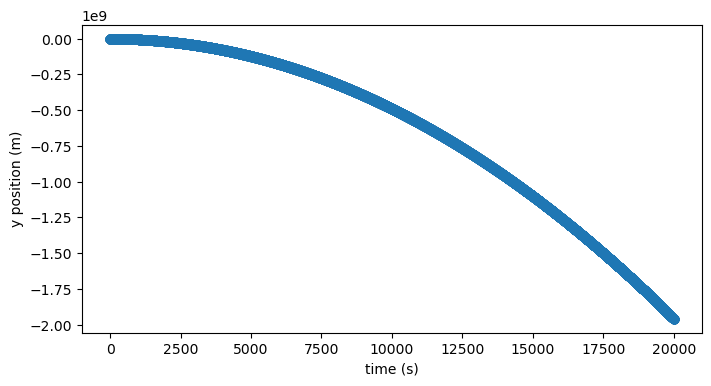

In [12]:
import numpy as np

in_file = open("parab_t_and_y_100k.csv", "r")
t_list = []
y_list = []
line = in_file.readline()        # read in the first line
while len(line) > 1:             # keep doing loop until there's no more data in the file
    line_list = line.split(",")  # split the string at each comma
    t = float(line_list[0])      # convert time string to a float
    y = float(line_list[1])      # convert position string to a float
    t_list.append(t)       
    y_list.append(y)
    line = in_file.readline()
    
# everything below here we'll worry about next tomorrow...
import matplotlib.pyplot as plt
t_arr = np.array(t_list)         
y_arr = np.array(y_list)         

fig = plt.figure(figsize=(8,4))
plt.plot(t_arr, y_arr, 'o')
plt.xlabel('time (s)')
plt.ylabel('y position (m)')
plt.show()

The data file that was read in above is a "**csv**" or "**comma-separated-value*" file.  This is very similar to the way that, say, Excel stores data, but we're able to access it directly.

`python` offers some really elegant ways of dealing with strings, but the basic tools in the code block above are soooooo useful.  We'll return to them many times in this workshop.

**Now you may ask yourself** why on Earth would I go to the trouble of programming in `python` something simple like this?  Couldn't I do this with Excel in 5-ish minutes?  That is truly a great question, and I can offer you TEN MILLION compelling answers.  I will exercise restraint and offer you only two here:
1. In this one block of code, we've basically reached the limit of what Excel is capable of in terms of both graphing and formatting.  With general programming structures, however, the possibilities and opportunities for sophistication are endless.
2. Suppose we now want to graph a trajectory that has about one million data points.  Can Excel handle that?  Well, you'd first have to load the data into Excel, then apply whatever calculations you need to do, then call up a graph.  With the `python` code above, we simply change the name of the data file we want to access.  (In fact, there's another data file in this repository that has $10^5$ lines; take it for a test drive if you want.)
3. (I lied, I'm doing three.)  In doing all of this, WE DID NOT EDIT THE FILE CONTAINING THE DATA.  We read in the data, but we did not modify (and never had the opportunity to modify) the data.  This is completely different from the process of "programming" an Excel spreadsheet.  Using file I/O tools like these is safer and more scientificially sound.

***

## In summary

If you really want to get me going, ask "Yeah, but why wouldn't I just do this with Excel?"

Let's do a...

### Live demo with NBA data!

The file `NBA_game_data_2000-2014.csv` contains NBA game data (teams, dates, scores) from 15 seans of regular and post-season play. That's nearly 20k games!  Let's say that your instructor believes that the outcomes of some NBA games are determined by non-competitive factors (*i.e.*, some of the games are rigged).  Calculate the following quantities to begin investigating:
- total number of games
- fraction of total games that are won by fewer than 3 points
- fraction of total games that are won by the home team

In [18]:
nba_file = open("NBA_game_data_2000-2014.csv", "r")

num_games = 0
close_games = 0
home_wins = 0

line = nba_file.readline() # this line reads the header from the file.  Toss it!
line = nba_file.readline() # this line reads the first data

while len(line) > 1:
    num_games = num_games + 1
    # index 9 column is team 1 final, index 18 is team 2 final
    line_list = line.split(",")
    team1_final = int(line_list[9])
    team2_final = int(line_list[18])
    if abs(team1_final - team2_final) < 3:
        close_games = close_games + 1
    if team2_final > team1_final:
        home_wins = home_wins + 1

    line = nba_file.readline()

nba_file.close()
print("total number of games:", num_games)
print("number of close games:", close_games)
print("fraction of close games:", close_games / num_games)
print("number of home wins:", home_wins)
print("fraction of home wins:", home_wins / num_games)

total number of games: 19235
number of close games: 1931
fraction of close games: 0.10038991421887185
number of home wins: 11637
fraction of home wins: 0.6049909020015597


### Homework

#### 1. More NBA analysis
Return to the NBA game data from the demo above. Calculate:
- fraction of games that went to overtime
- fraction of home-team wins in which the home team was losing at the beginning of the 4th quarter
- fraction of games that the LA Lakers (most likely cheaters in the league) come from behind in the 4th quarter and won
